# Metal--ligand recognition prototype

This notebook illustrates the analyzer-level metal--ligand candidate records introduced for coordination chemistry. The key separation is:

- `ML/sigma-acceptor`: ligand-to-metal sigma donation into a metal acceptor channel.
- `ML/pi-donor`: metal-to-ligand pi back-donation, where the metal acts as the pi donor and the ligand acts as a pi acceptor.

The records are analyzer diagnostics. They are not automatic NBO Lewis assignments and they are not automatic VB active-space choices.

In [13]:
from pathlib import Path
import importlib.util
import sys

# Prefer the source tree when the notebook is run from the repository or docs/.
def find_repo_root(start):
    for path in (start, *start.parents):
        if (path / 'src' / 'pymodule').exists():
            return path
    return start


def load_source_module(module_name, relative_file):
    sys.modules.pop(module_name, None)
    module_path = repo / 'src' / 'pymodule' / relative_file
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


repo = find_repo_root(Path.cwd().resolve())
import veloxchem

source_pkg = str((repo / 'src' / 'pymodule').resolve())
if source_pkg not in veloxchem.__path__:
    veloxchem.__path__.insert(0, source_pkg)

analyzer_module = load_source_module(
    'veloxchem.orbitalanalyzerdriver',
    'orbitalanalyzerdriver.py',
)
nbodriver_module = load_source_module('veloxchem.nbodriver', 'nbodriver.py')
vbdriver_module = load_source_module('veloxchem.vbdriver', 'vbdriver.py')
veloxchem.NboDriver = nbodriver_module.NboDriver
veloxchem.VbDriver = vbdriver_module.VbDriver

from veloxchem.molecule import Molecule

print('Repository root:', repo)
print('NboDriver module:', nbodriver_module.__file__)
print('VbDriver module:', vbdriver_module.__file__)
print('OrbitalAnalyzer module:', analyzer_module.__file__)

Repository root: /home/linares/app/VeloxChem
NboDriver module: /home/linares/app/VeloxChem/src/pymodule/nbodriver.py
VbDriver module: /home/linares/app/VeloxChem/src/pymodule/vbdriver.py
OrbitalAnalyzer module: /home/linares/app/VeloxChem/src/pymodule/orbitalanalyzerdriver.py


## Real Pd--ligand setup

The notebook uses the public VeloxChem-style workflow: build a molecule and basis, run SCF, call `NboDriver.compute()`, then pass the same NAO payload to `VbDriver.compute()`. No mock NAO payloads or monkeypatching are used.

In [2]:
def pd_ligand_molecule(ligand):
    if ligand == 'NH3':
        xyz = '''
Pd  0.0000  0.0000  0.0000
N   2.0500  0.0000  0.0000
H   2.4500  0.9300  0.0000
H   2.4500 -0.4650  0.8050
H   2.4500 -0.4650 -0.8050
'''
    elif ligand == 'PH3':
        xyz = '''
Pd  0.0000  0.0000  0.0000
P   2.2500  0.0000  0.0000
H   2.8500  1.1500  0.0000
H   2.8500 -0.5750  0.9960
H   2.8500 -0.5750 -0.9960
'''
    else:
        raise ValueError(ligand)
    molecule = Molecule.read_str(xyz)
    molecule.set_charge(0)
    molecule.set_multiplicity(1)
    return molecule


def summarize_metal_ligand(records):
    rows = []
    for record in records:
        rows.append({
            'subtype': record['subtype'],
            'channel': record['channel'],
            'metal': record.get('metal_atom'),
            'ligand': record.get('ligand_atom'),
            'donation': round(float(record.get('donation_strength', 0.0)), 6),
            'back_donation': round(float(record.get('back_donation_strength', 0.0)), 6),
            'role': record.get('donor_acceptor_role'),
        })
    return rows


def run_real_metal_ligand_nbo(ligand, basis_label='def2-svp'):
    molecule = pd_ligand_molecule(ligand)
    basis = veloxchem.MolecularBasis.read(molecule, basis_label, ostream=None)

    scf = veloxchem.ScfRestrictedDriver()
    scf.ostream.mute()
    scf.xcfun = 'hf'
    scf.compute(molecule, basis)

    nbo_driver = nbodriver_module.NboDriver()
    nbo_driver.verbose = False
    nbo_driver.ostream.mute()
    results = nbo_driver.compute(
        molecule,
        basis,
        scf.mol_orbs,
        options=nbodriver_module.NboComputeOptions(
            include_diagnostics=True,
            include_mo_analysis=False,
            max_alternatives=0,
        ),
    )
    report = nbo_driver.nbo_report(level='full', return_text=True)
    return molecule, basis, results, report


def run_real_metal_ligand_vb(molecule, basis, nao_data, channels, mode='vbci'):
    return vbdriver_module.VbDriver().compute(
        molecule,
        basis,
        options=vbdriver_module.VbComputeOptions(
            mode=mode,
            optimize_orbitals=False,
            active_metal_ligand_channels=tuple(channels),
            freeze_inactive_orbitals=True,
            max_iter=20,
        ),
        nao_data=nao_data,
    )


def run_real_metal_ligand_vbci(molecule, basis, nao_data, channels):
    return run_real_metal_ligand_vb(
        molecule,
        basis,
        nao_data,
        channels,
        mode='vbci',
    )


def run_real_metal_ligand_bovb(molecule, basis, nao_data, channels):
    return run_real_metal_ligand_vb(
        molecule,
        basis,
        nao_data,
        channels,
        mode='bovb',
    )


def summarize_vb_model(result):
    diagnostics = result['diagnostics']
    row = {
        'model': diagnostics.get('metal_ligand_model'),
        'channels': diagnostics.get('metal_ligand_channels'),
        'backdonation_enabled': diagnostics.get('metal_ligand_backdonation_enabled'),
        'energy': round(float(result['energy']), 8),
        'active_orbitals': diagnostics.get('active_orbital_count'),
        'active_electrons': diagnostics.get('active_electron_count'),
        'determinants': diagnostics.get('determinant_count'),
    }
    if diagnostics.get('vb_method') == 'bovb':
        row.update({
            'bovb_lowering': round(
                float(diagnostics.get('metal_ligand_bovb_energy_lowering', 0.0)),
                8,
            ),
            'external_breathing': diagnostics.get(
                'metal_ligand_bovb_has_external_breathing_space'),
        })
    return row


summarize_vbci_model = summarize_vb_model


def metal_ligand_report_excerpt(report):
    marker = 'Metal-ligand diagnostics (ML)'
    if marker not in report:
        return 'No metal-ligand diagnostics section was printed.'
    return report[report.index(marker):]

## Real SCF Pd--NH3 and Pd--PH3 NBO diagnostics

These cells run real Hartree--Fock calculations with `def2-svp`, then pass the resulting molecular orbitals to `NboDriver.compute()`. The checks below verify that metal--ligand records are exposed as diagnostics and remain outside the occupied Lewis assignment.

In [3]:
real_runs = {}
for label, ligand in {'Pd--NH3': 'NH3', 'Pd--PH3': 'PH3'}.items():
    molecule, basis, results, report = run_real_metal_ligand_nbo(
        ligand,
        basis_label='def2-svp',
    )
    real_runs[label] = {
        'molecule': molecule,
        'basis': basis,
        'results': results,
        'report': report,
        'nao_data': results['orbital_analysis'].nao_data,
        'summary': summarize_metal_ligand(results['metal_ligand_diagnostics']),
    }
    print(f'\n{label}')
    for row in real_runs[label]['summary']:
        print(row)
    print('NBO primary has ML:', any(candidate.get('type') == 'ML'
                                     for candidate in results['nbo_list']))


Pd--NH3
{'subtype': 'pi-donor', 'channel': 'metal-to-ligand-pi-back-donation', 'metal': 1, 'ligand': 2, 'donation': 0.0, 'back_donation': 0.243218, 'role': 'metal pi donor / ligand pi nonbonding-or-acceptor'}
{'subtype': 'sigma-acceptor', 'channel': 'ligand-to-metal-sigma-donation', 'metal': 1, 'ligand': 2, 'donation': 0.0, 'back_donation': 0.0, 'role': 'ligand sigma donor / metal acceptor'}
NBO primary has ML: False

Pd--PH3
{'subtype': 'pi-donor', 'channel': 'metal-to-ligand-pi-back-donation', 'metal': 1, 'ligand': 2, 'donation': 0.0, 'back_donation': 0.493471, 'role': 'metal pi donor / ligand pi nonbonding-or-acceptor'}
{'subtype': 'sigma-acceptor', 'channel': 'ligand-to-metal-sigma-donation', 'metal': 1, 'ligand': 2, 'donation': 0.0, 'back_donation': 0.0, 'role': 'ligand sigma donor / metal acceptor'}
NBO primary has ML: False


In [4]:
for label, payload in real_runs.items():
    results = payload['results']
    report = payload['report']
    summary = payload['summary']

    assert summary, f'{label} produced no metal-ligand diagnostics'
    assert not any(candidate.get('type') == 'ML' for candidate in results['nbo_list'])
    assert 'Metal-ligand diagnostics (ML)' in report
    assert 'diagnostics only' in report
    assert 'Pd1' in report
    assert 'sigma-acceptor' in report or 'pi-donor' in report

print(metal_ligand_report_excerpt(real_runs['Pd--PH3']['report']))

Metal-ligand diagnostics (ML)
--------------------------------------------------------------------------------------------------------
These channels are diagnostics only and are not selected occupied Lewis NBOs.
Metal    Ligand   Subtype          Mode             Occ   Donation  Back-don.   Strength  Channel
--------------------------------------------------------------------------------------------------------
Pd1      P2       pi-donor         terminal     1.27625   0.000000   0.493471   0.493471  metal-to-ligand-pi-back-donation
      Role: metal pi donor / ligand pi nonbonding-or-acceptor
Pd1      P2       sigma-acceptor   terminal     0.43941   0.000000   0.000000   0.000000  ligand-to-metal-sigma-donation
      Role: ligand sigma donor / metal acceptor


## Real VB-CI: blocked versus authorized back-donation

The fixed-orbital VB-CI comparison uses the same real SCF/NAO payload. The sigma-only model blocks metal-to-ligand back-donation by activating only `sigma-acceptor`; the sigma-plus-back-donation model authorizes it by activating both `sigma-acceptor` and `pi-donor`.

In [5]:
vbci_runs = {}
model_channels = {
    'sigma-only': ('sigma-acceptor',),
    'sigma-plus-backdonation': ('sigma-acceptor', 'pi-donor'),
}

for label, payload in real_runs.items():
    vbci_runs[label] = {}
    print(f'\n{label}')
    for model, channels in model_channels.items():
        result = run_real_metal_ligand_vbci(
            payload['molecule'],
            payload['basis'],
            payload['nao_data'],
            channels,
        )
        vbci_runs[label][model] = result
        print(model, summarize_vbci_model(result))

    delta = (vbci_runs[label]['sigma-plus-backdonation']['energy'] -
             vbci_runs[label]['sigma-only']['energy'])
    print('Delta_E_authorize_backdonation:', round(float(delta), 8))

for label, runs in vbci_runs.items():
    blocked = runs['sigma-only']['diagnostics']
    authorized = runs['sigma-plus-backdonation']['diagnostics']
    assert blocked['metal_ligand_model'] == 'sigma-only'
    assert blocked['metal_ligand_backdonation_enabled'] is False
    assert blocked['metal_ligand_channels'] == ('sigma-acceptor',)
    assert authorized['metal_ligand_model'] == 'sigma-plus-backdonation'
    assert authorized['metal_ligand_backdonation_enabled'] is True
    assert authorized['metal_ligand_channels'] == ('sigma-acceptor', 'pi-donor')
    assert authorized['active_orbital_count'] > blocked['active_orbital_count']


Pd--NH3
sigma-only {'model': 'sigma-only', 'channels': ('sigma-acceptor',), 'backdonation_enabled': False, 'energy': -7.9398194, 'active_orbitals': 2, 'active_electrons': 2, 'determinants': 4}
sigma-plus-backdonation {'model': 'sigma-plus-backdonation', 'channels': ('sigma-acceptor', 'pi-donor'), 'backdonation_enabled': True, 'energy': -87.20153035, 'active_orbitals': 4, 'active_electrons': 4, 'determinants': 36}
Delta_E_authorize_backdonation: -79.26171095

Pd--PH3
sigma-only {'model': 'sigma-only', 'channels': ('sigma-acceptor',), 'backdonation_enabled': False, 'energy': 24.3789243, 'active_orbitals': 2, 'active_electrons': 2, 'determinants': 4}
sigma-plus-backdonation {'model': 'sigma-plus-backdonation', 'channels': ('sigma-acceptor', 'pi-donor'), 'backdonation_enabled': True, 'energy': -43.79736178, 'active_orbitals': 4, 'active_electrons': 4, 'determinants': 36}
Delta_E_authorize_backdonation: -68.17628609


## Real BOVB: blocked versus authorized back-donation

The BOVB comparison uses the same real SCF/NAO payload and the same channel switches. The zero-amplitude determinant-CI limit is kept as an internal reference, and the reported lowering is the variational gain from center-local metal-ligand breathing orbitals.

In [6]:
bovb_runs = {}

for label, payload in real_runs.items():
    bovb_runs[label] = {}
    print(f'\n{label}')
    for model, channels in model_channels.items():
        result = run_real_metal_ligand_bovb(
            payload['molecule'],
            payload['basis'],
            payload['nao_data'],
            channels,
        )
        bovb_runs[label][model] = result
        print(model, summarize_vb_model(result))

    delta = (bovb_runs[label]['sigma-plus-backdonation']['energy'] -
             bovb_runs[label]['sigma-only']['energy'])
    print('Delta_E_authorize_backdonation_BOVB:', round(float(delta), 8))

for label, runs in bovb_runs.items():
    blocked = runs['sigma-only']['diagnostics']
    authorized = runs['sigma-plus-backdonation']['diagnostics']
    assert blocked['metal_ligand_model'] == 'sigma-only'
    assert blocked['metal_ligand_backdonation_enabled'] is False
    assert blocked['metal_ligand_bovb_has_external_breathing_space'] is True
    assert blocked['metal_ligand_bovb_energy_lowering'] >= -1.0e-10
    assert authorized['metal_ligand_model'] == 'sigma-plus-backdonation'
    assert authorized['metal_ligand_backdonation_enabled'] is True
    assert authorized['metal_ligand_channels'] == ('sigma-acceptor', 'pi-donor')
    assert authorized['metal_ligand_bovb_has_external_breathing_space'] is True
    assert authorized['metal_ligand_bovb_energy_lowering'] >= -1.0e-10
    assert authorized['active_orbital_count'] > blocked['active_orbital_count']


Pd--NH3
sigma-only {'model': 'sigma-only', 'channels': ('sigma-acceptor',), 'backdonation_enabled': False, 'energy': -8.18825054, 'active_orbitals': 2, 'active_electrons': 2, 'determinants': 4, 'bovb_lowering': 0.24843114, 'external_breathing': True}
sigma-plus-backdonation {'model': 'sigma-plus-backdonation', 'channels': ('sigma-acceptor', 'pi-donor'), 'backdonation_enabled': True, 'energy': -139.82642053, 'active_orbitals': 4, 'active_electrons': 4, 'determinants': 36, 'bovb_lowering': 52.62489018, 'external_breathing': True}
Delta_E_authorize_backdonation_BOVB: -131.63816999

Pd--PH3
sigma-only {'model': 'sigma-only', 'channels': ('sigma-acceptor',), 'backdonation_enabled': False, 'energy': 23.85059152, 'active_orbitals': 2, 'active_electrons': 2, 'determinants': 4, 'bovb_lowering': 0.52833278, 'external_breathing': True}
sigma-plus-backdonation {'model': 'sigma-plus-backdonation', 'channels': ('sigma-acceptor', 'pi-donor'), 'backdonation_enabled': True, 'energy': -79.84434381, 'ac

## Pd--ligand constrained dissociation scan

The scan below prepares constrained Pd--ligand geometries at B3LYP/def2-SVP from a short repulsive distance out to 5.0 Angstrom. HF/NBO single-point calculations are then evaluated on those geometries.

The potential-energy curves use `E(R) - E(5.0 Angstrom)` in kJ/mol, so a physically useful curve should show a negative well and return to zero at 5.0 Angstrom. The B3LYP and HF curves are treated as validated reference dissociation curves. The current VB-SCF/BOVB sigma traces are kept in a separate diagnostic panel because the metal-ligand VB total-energy model is still not reliable enough to be interpreted as a production dissociation curve.

In [19]:
import tempfile

import numpy as np
import matplotlib.pyplot as plt

HARTREE_TO_KJMOL = 2625.499638
BOHR_TO_ANGSTROM = 0.529177210903
ML_SIGMA_TRACKING_THRESHOLD = 1.0e-6

scan_definitions = {
    'Pd--NH3': {
        'ligand': 'NH3',
        'start': 1.65,
        'stop': 5.00,
        'points': 13,
    },
    'Pd--PH3': {
        'ligand': 'PH3',
        'start': 1.80,
        'stop': 5.00,
        'points': 13,
    },
}

vb_energy_models = {
    'sigma': ('sigma-acceptor',),
}


def pd_ligand_molecule_at_distance(ligand, distance):
    distance = float(distance)
    if ligand == 'NH3':
        hx = distance + 0.4000
        xyz = f'''
Pd  0.0000  0.0000  0.0000
N   {distance:.8f}  0.0000  0.0000
H   {hx:.8f}  0.9300  0.0000
H   {hx:.8f} -0.4650  0.8050
H   {hx:.8f} -0.4650 -0.8050
'''
    elif ligand == 'PH3':
        hx = distance + 0.6000
        xyz = f'''
Pd  0.0000  0.0000  0.0000
P   {distance:.8f}  0.0000  0.0000
H   {hx:.8f}  1.1500  0.0000
H   {hx:.8f} -0.5750  0.9960
H   {hx:.8f} -0.5750 -0.9960
'''
    else:
        raise ValueError(ligand)
    molecule = Molecule.read_str(xyz)
    molecule.set_charge(0)
    molecule.set_multiplicity(1)
    return molecule


def pd_ligand_distance(molecule):
    coords = molecule.get_coordinates_in_bohr() * BOHR_TO_ANGSTROM
    return float(np.linalg.norm(coords[1] - coords[0]))


def molecule_from_xyz_string(xyz_string, charge=0, multiplicity=1):
    molecule = Molecule.read_xyz_string(xyz_string)
    molecule.set_charge(charge)
    molecule.set_multiplicity(multiplicity)
    return molecule


def cached_scan_matches(geometries, start, stop, points):
    if len(geometries) != int(points):
        return False
    targets = np.array([geometry['target_distance'] for geometry in geometries])
    expected = np.linspace(float(start), float(stop), int(points))
    return np.allclose(targets, expected, atol=1.0e-8)


def run_b3lyp_constrained_pd_ligand_scan(ligand, start, stop, points, basis_label='def2-svp'):
    molecule = pd_ligand_molecule_at_distance(ligand, start)
    basis = veloxchem.MolecularBasis.read(molecule, basis_label, ostream=None)

    with tempfile.TemporaryDirectory() as scratch:
        filename = str(Path(scratch) / f'pd_{ligand.lower()}_b3lyp_scan')

        scf = veloxchem.ScfRestrictedDriver()
        scf.ostream.mute()
        scf.xcfun = 'b3lyp'
        scf.filename = filename

        opt = veloxchem.OptimizationDriver(scf)
        opt.ostream.mute()
        opt.filename = filename
        opt.restart = False
        opt.max_iter = 100
        opt.constraints = [
            f'scan distance 1 2 {float(start):.8f} {float(stop):.8f} {int(points)}'
        ]
        opt_results = opt.compute(molecule, basis)

    geometries = []
    target_distances = np.linspace(float(start), float(stop), int(points))
    for target_distance, dft_energy, xyz_string in zip(
            target_distances,
            opt_results['scan_energies'],
            opt_results['scan_geometries']):
        scan_molecule = molecule_from_xyz_string(xyz_string)
        geometries.append({
            'target_distance': float(target_distance),
            'distance': pd_ligand_distance(scan_molecule),
            'b3lyp_scan_energy': float(dft_energy),
            'molecule': scan_molecule,
            'xyz': xyz_string,
        })
    return geometries


def run_real_metal_ligand_nbo_at_geometry(molecule, basis_label='def2-svp'):
    basis = veloxchem.MolecularBasis.read(molecule, basis_label, ostream=None)

    scf = veloxchem.ScfRestrictedDriver()
    scf.ostream.mute()
    scf.xcfun = 'hf'
    scf_results = scf.compute(molecule, basis)

    nbo_driver = nbodriver_module.NboDriver()
    nbo_driver.verbose = False
    nbo_driver.ostream.mute()
    results = nbo_driver.compute(
        molecule,
        basis,
        scf.mol_orbs,
        options=nbodriver_module.NboComputeOptions(
            include_diagnostics=True,
            include_mo_analysis=False,
            max_alternatives=0,
        ),
    )
    return basis, results, float(scf_results['scf_energy']), scf.mol_orbs


def run_real_metal_ligand_vb_at_geometry(
        molecule,
        basis,
        mol_orbs,
        channels,
        mode,
        reference_orbitals=None,
        max_iter=20):
    analyzer_options = analyzer_module.OrbitalAnalyzerOptions(include_mo_analysis=False)
    analysis = analyzer_module.OrbitalAnalyzer(
        molecule,
        basis,
        mol_orbs=mol_orbs,
        options=analyzer_options,
    ).run()
    options = vbdriver_module.VbComputeOptions(
        mode=mode,
        max_iter=max_iter,
        active_metal_ligand_channels=tuple(channels),
        active_metal_ligand_reference_orbitals=reference_orbitals,
        freeze_inactive_orbitals=True,
    )
    return vbdriver_module.VbDriver().compute(
        molecule,
        basis,
        reference_orbitals=mol_orbs,
        options=options,
        nao_data=analysis.nao_data,
    )


def make_metal_ligand_reference_orbitals(molecule, basis, mol_orbs, channels):
    anchor = run_real_metal_ligand_vb_at_geometry(
        molecule,
        basis,
        mol_orbs,
        channels,
        mode='vbscf',
        reference_orbitals=None,
        max_iter=1,
    )
    return tuple(anchor['active_space'].active_orbitals)


def vb_total_energy(result):
    diagnostics = result.get('diagnostics', {})
    if not diagnostics.get('energy_represents_total_dissociation_energy', False):
        raise RuntimeError(
            'VB result is not state-tracked and must not be plotted as a dissociation energy.'
        )
    return float(diagnostics.get('vb_total_energy', result['energy']))


def ml_record_strength(results, subtype):
    records = [
        record for record in results.get('nbo_candidates', [])
        if record.get('type') == 'ML' and record.get('subtype') == subtype
    ]
    if not records:
        return 0.0
    return max(float(record.get('interaction_strength', 0.0)) for record in records)

In [8]:
scan_geometries = globals().get('scan_geometries', {})


Pd--NH3: using cached B3LYP/def2-SVP constrained geometries
Pd--NH3: HF/NBO/state-tracked sigma VB single points
{'system': 'Pd--NH3', 'target_distance': 1.65, 'distance': 1.65, 'b3lyp_scan_energy': -184.36150945, 'hf_scf_energy': -183.05419752, 'sigma_strength': 0.0, 'pi_strength': 0.51609841, 'vbscf_sigma_energy': -182.88170284, 'bovb_sigma_energy': -186.89701815}
{'system': 'Pd--NH3', 'target_distance': 1.92916667, 'distance': 1.92916667, 'b3lyp_scan_energy': -184.42663782, 'hf_scf_energy': -183.13882512, 'sigma_strength': 0.0, 'pi_strength': 0.29652964, 'vbscf_sigma_energy': -182.98770371, 'bovb_sigma_energy': -187.23053834}
{'system': 'Pd--NH3', 'target_distance': 2.20833333, 'distance': 2.20833334, 'b3lyp_scan_energy': -184.43142871, 'hf_scf_energy': -183.15768041, 'sigma_strength': 0.0, 'pi_strength': 0.141642, 'vbscf_sigma_energy': -183.26696826, 'bovb_sigma_energy': -187.68239502}
{'system': 'Pd--NH3', 'target_distance': 2.4875, 'distance': 2.4875, 'b3lyp_scan_energy': -184.4

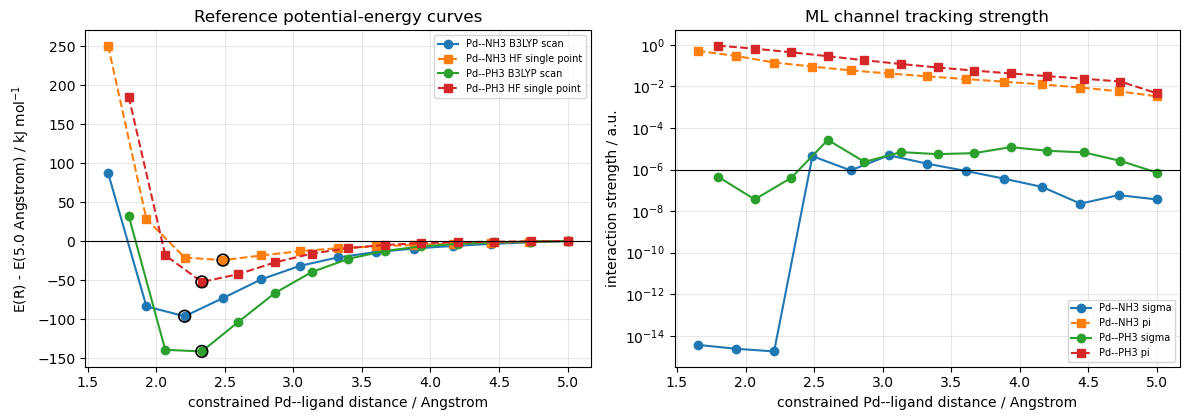

Reference potential minima on the scan grid
System   Method              R_min / A      E_min-E_5A / kJ mol-1   Boundary
----------------------------------------------------------------------------
Pd--NH3  B3LYP scan             2.2083                     -96.42      False
Pd--NH3  HF single point        2.4875                     -24.47      False
Pd--PH3  B3LYP scan             2.3333                    -141.54      False
Pd--PH3  HF single point        2.3333                     -52.41      False


In [21]:
scan_rows = []
try:
    scan_geometries
except NameError:
    scan_geometries = {}

vb_reference_orbitals = {}
for label, definition in scan_definitions.items():
    ligand = definition['ligand']
    geometries = scan_geometries.get(label)
    if not geometries or not cached_scan_matches(
            geometries,
            definition['start'],
            definition['stop'],
            definition['points']):
        print(f'\n{label}: B3LYP/def2-SVP constrained geometry scan')
        geometries = run_b3lyp_constrained_pd_ligand_scan(
            ligand,
            definition['start'],
            definition['stop'],
            definition['points'],
            basis_label='def2-svp',
        )
        scan_geometries[label] = geometries
    else:
        print(f'\n{label}: using cached B3LYP/def2-SVP constrained geometries')

    print(f'{label}: HF/NBO/state-tracked sigma VB single points')
    for geometry in geometries:
        molecule = geometry['molecule']
        basis, results, hf_energy, mol_orbs = run_real_metal_ligand_nbo_at_geometry(
            molecule,
            basis_label='def2-svp',
        )
        b3lyp_energy = geometry.get('b3lyp_scan_energy', geometry.get('dft_energy'))
        sigma_strength = ml_record_strength(results, 'sigma-acceptor')
        pi_strength = ml_record_strength(results, 'pi-donor')

        row = {
            'system': label,
            'target_distance': float(geometry['target_distance']),
            'distance': float(geometry['distance']),
            'b3lyp_scan_energy': float(b3lyp_energy),
            'hf_scf_energy': float(hf_energy),
            'sigma_strength': float(sigma_strength),
            'pi_strength': float(pi_strength),
        }

        for model, channels in vb_energy_models.items():
            reference_key = (label, model)
            if reference_key not in vb_reference_orbitals:
                vb_reference_orbitals[reference_key] = make_metal_ligand_reference_orbitals(
                    molecule,
                    basis,
                    mol_orbs,
                    channels,
                )
            reference_orbitals = vb_reference_orbitals[reference_key]
            vbscf_result = run_real_metal_ligand_vb_at_geometry(
                molecule,
                basis,
                mol_orbs,
                channels,
                mode='vbscf',
                reference_orbitals=reference_orbitals,
                max_iter=1,
            )
            bovb_result = run_real_metal_ligand_vb_at_geometry(
                molecule,
                basis,
                mol_orbs,
                channels,
                mode='bovb',
                reference_orbitals=reference_orbitals,
                max_iter=20,
            )
            row[f'vbscf_{model}_energy'] = vb_total_energy(vbscf_result)
            row[f'bovb_{model}_energy'] = vb_total_energy(bovb_result)
            row[f'vbscf_{model}_embedded_energy'] = float(
                vbscf_result['diagnostics']['embedded_active_space_energy']
            )
            row[f'bovb_{model}_embedded_energy'] = float(
                bovb_result['diagnostics']['embedded_active_space_energy']
            )

        scan_rows.append(row)
        print({
            key: round(value, 8) if isinstance(value, float) else value
            for key, value in row.items()
            if not key.endswith('_embedded_energy')
        })

energy_keys = [
    'b3lyp_scan_energy',
    'hf_scf_energy',
    'vbscf_sigma_energy',
    'bovb_sigma_energy',
]
reference_energy_keys = [
    'b3lyp_scan_energy',
    'hf_scf_energy',
]
vb_diagnostic_energy_keys = [
    'vbscf_sigma_energy',
    'bovb_sigma_energy',
]
relative_energy_keys = [key.replace('_energy', '_relative_kjmol') for key in energy_keys]
minimum_rows = []

for label in scan_definitions:
    rows = sorted(
        [row for row in scan_rows if row['system'] == label],
        key=lambda row: row['distance'],
    )
    zeros = {key: rows[-1][key] for key in energy_keys}
    for row in rows:
        for key in energy_keys:
            row[key.replace('_energy', '_relative_kjmol')] = (
                row[key] - zeros[key]) * HARTREE_TO_KJMOL

    for key in reference_energy_keys:
        minimum = min(rows, key=lambda row: row[key])
        minimum_index = rows.index(minimum)
        minimum_rows.append({
            'system': label,
            'method': key,
            'distance': minimum['distance'],
            'relative_kjmol': minimum[key.replace('_energy', '_relative_kjmol')],
            'is_boundary': minimum_index in (0, len(rows) - 1),
        })

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=False)
reference_styles = {
    'b3lyp_scan_relative_kjmol': ('o', '-', 'B3LYP scan'),
    'hf_scf_relative_kjmol': ('s', '--', 'HF single point'),
}

for label in scan_definitions:
    rows = sorted(
        [row for row in scan_rows if row['system'] == label],
        key=lambda row: row['distance'],
    )
    distances = np.array([row['distance'] for row in rows])

    for key, (marker, linestyle, method_label) in reference_styles.items():
        values = np.array([row[key] for row in rows])
        axes[0].plot(
            distances,
            values,
            marker=marker,
            linestyle=linestyle,
            label=f'{label} {method_label}',
        )
        minimum_index = int(np.argmin(values))
        axes[0].scatter(
            [distances[minimum_index]],
            [values[minimum_index]],
            s=70,
            facecolors='none',
            edgecolors='black',
            linewidths=1.2,
            zorder=5,
        )

    axes[1].semilogy(
        distances,
        [row['sigma_strength'] for row in rows],
        marker='o',
        label=f'{label} sigma',
    )
    axes[1].semilogy(
        distances,
        [row['pi_strength'] for row in rows],
        marker='s',
        linestyle='--',
        label=f'{label} pi',
    )

axes[0].set_title('Reference potential-energy curves')
axes[0].set_xlabel('constrained Pd--ligand distance / Angstrom')
axes[0].set_ylabel('E(R) - E(5.0 Angstrom) / kJ mol$^{-1}$')
axes[0].axhline(0.0, color='black', linewidth=0.8)
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].set_title('ML channel tracking strength')
axes[1].set_xlabel('constrained Pd--ligand distance / Angstrom')
axes[1].set_ylabel('interaction strength / a.u.')
axes[1].axhline(ML_SIGMA_TRACKING_THRESHOLD, color='black', linewidth=0.8)
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Reference potential minima on the scan grid')
print('=' * 76)
print(f"{'System':<8} {'Method':<18} {'R_min / A':>10} {'E_min-E_5A / kJ mol-1':>26} {'Boundary':>10}")
print('-' * 76)
for entry in minimum_rows:
    method_name = {
        'b3lyp_scan_energy': 'B3LYP scan',
        'hf_scf_energy': 'HF single point',
    }[entry['method']]
    print(
        f"{entry['system']:<8} {method_name:<18} {entry['distance']:>10.4f} "
        f"{entry['relative_kjmol']:>26.2f} {str(entry['is_boundary']):>10}"
    )
print('=' * 76)

for row in scan_rows:
    for key in relative_energy_keys:
        assert np.isfinite(row[key])
    assert row['distance'] <= 5.0 + 1.0e-5
    assert row['sigma_strength'] >= 0.0
    assert row['pi_strength'] >= 0.0

for entry in minimum_rows:
    assert not entry['is_boundary'], (
        f"{entry['system']} {entry['method']} minimum is at the scan boundary; "
        'extend the scan before interpreting a dissociation energy.'
    )

In [22]:
dissociation_energy_rows = []
validated_dissociation_energy_keys = {
    'b3lyp_scan_energy': 'B3LYP constrained scan',
    'hf_scf_energy': 'HF single point',
}
vb_diagnostic_energy_keys = {
    'vbscf_sigma_energy': 'VBSCF sigma diagnostic',
    'bovb_sigma_energy': 'BOVB sigma diagnostic',
}

for label in scan_definitions:
    rows = sorted(
        [row for row in scan_rows if row['system'] == label],
        key=lambda row: row['distance'],
    )
    if not rows:
        continue
    asymptote = rows[-1]
    for key, method_label in validated_dissociation_energy_keys.items():
        minimum = min(rows, key=lambda row: row[key])
        minimum_index = rows.index(minimum)
        de_kjmol = (asymptote[key] - minimum[key]) * HARTREE_TO_KJMOL
        relative_key = key.replace('_energy', '_relative_kjmol')
        dissociation_energy_rows.append({
            'system': label,
            'method': method_label,
            'r_min_angstrom': float(minimum['distance']),
            'r_asymptote_angstrom': float(asymptote['distance']),
            'e_min_hartree': float(minimum[key]),
            'e_asymptote_hartree': float(asymptote[key]),
            'dissociation_energy_kjmol': float(de_kjmol),
            'relative_energy_at_minimum_kjmol': float(minimum[relative_key]),
            'minimum_is_boundary': minimum_index in (0, len(rows) - 1),
        })

print('Validated reference dissociation energies relative to the 5.0 Angstrom point')
print('=' * 124)
print(
    f"{'System':<8} {'Method':<24} {'R_min / A':>10} {'R_inf / A':>10} "
    f"{'E_min / Eh':>16} {'E_5A / Eh':>16} {'D_e / kJ mol-1':>18} {'Boundary':>10}"
)
print('-' * 124)
for entry in dissociation_energy_rows:
    print(
        f"{entry['system']:<8} {entry['method']:<24} "
        f"{entry['r_min_angstrom']:>10.4f} {entry['r_asymptote_angstrom']:>10.4f} "
        f"{entry['e_min_hartree']:>16.8f} {entry['e_asymptote_hartree']:>16.8f} "
        f"{entry['dissociation_energy_kjmol']:>18.2f} "
        f"{str(entry['minimum_is_boundary']):>10}"
    )
print('=' * 124)

for entry in dissociation_energy_rows:
    assert np.isfinite(entry['dissociation_energy_kjmol'])
    assert entry['dissociation_energy_kjmol'] >= -1.0e-8
    assert not entry['minimum_is_boundary'], (
        f"{entry['system']} {entry['method']} minimum is at the scan boundary; "
        'extend the scan before interpreting D_e.'
    )

vb_diagnostic_rows = []
for label in scan_definitions:
    rows = sorted(
        [row for row in scan_rows if row['system'] == label],
        key=lambda row: row['distance'],
    )
    asymptote = rows[-1]
    for key, method_label in vb_diagnostic_energy_keys.items():
        minimum = min(rows, key=lambda row: row[key])
        minimum_index = rows.index(minimum)
        vb_diagnostic_rows.append({
            'system': label,
            'method': method_label,
            'r_min_angstrom': float(minimum['distance']),
            'relative_minimum_kjmol': float(
                (minimum[key] - asymptote[key]) * HARTREE_TO_KJMOL
            ),
            'minimum_is_boundary': minimum_index in (0, len(rows) - 1),
        })

print('\nVB sigma diagnostic extrema, not validated dissociation energies')
print('=' * 84)
print(f"{'System':<8} {'Method':<24} {'R_min / A':>10} {'E_min-E_5A / kJ mol-1':>26} {'Boundary':>10}")
print('-' * 84)
for entry in vb_diagnostic_rows:
    print(
        f"{entry['system']:<8} {entry['method']:<24} {entry['r_min_angstrom']:>10.4f} "
        f"{entry['relative_minimum_kjmol']:>26.2f} {str(entry['minimum_is_boundary']):>10}"
    )
print('=' * 84)

Validated reference dissociation energies relative to the 5.0 Angstrom point
System   Method                    R_min / A  R_inf / A       E_min / Eh        E_5A / Eh     D_e / kJ mol-1   Boundary
----------------------------------------------------------------------------------------------------------------------------
Pd--NH3  B3LYP constrained scan       2.2083     5.0000    -184.43142871    -184.39470292              96.42      False
Pd--NH3  HF single point              2.4875     5.0000    -183.15892131    -183.14960143              24.47      False
Pd--PH3  B3LYP constrained scan       2.3333     5.0000    -470.99240287    -470.93849489             141.54      False
Pd--PH3  HF single point              2.3333     5.0000    -469.38422086    -469.36425747              52.41      False

VB sigma diagnostic extrema, not validated dissociation energies
System   Method                    R_min / A      E_min-E_5A / kJ mol-1   Boundary
-------------------------------------------------

The validated dissociation energy reported above is the grid value

\[
D_e(5.0\ \mathrm{A}) = E(5.0\ \mathrm{A}) - \min_R E(R),
\]

converted to kJ mol^-1. The 5.0 A point is the common dissociation zero. The table rejects boundary minima so a reported value cannot come from a scan that never found the bottom of the well. VBSCF and BOVB sigma results are printed only as diagnostics until their metal-ligand total-energy model gives physically stable potential curves.

## Why the VB curves are diagnostic

The earlier large VB-SCF/BOVB jumps had two concrete implementation causes: the metal-ligand active space was being regenerated at each distance, and the VB AO Hamiltonian did not include the same effective-charge/ECP one-electron terms as the SCF driver for Pd/def2-SVP.

Those implementation bugs were fixed, but the remaining sigma-only metal-ligand VB model still does not yet produce reliable production dissociation curves for Pd--NH3 and Pd--PH3. The notebook therefore no longer reports VB-SCF/BOVB sigma traces as validated dissociation energies. They remain plotted as diagnostics beside the NBO metal-ligand channel strengths while the B3LYP and HF curves provide the physically interpretable reference scan.

## Interpretation

The calculation above is a real API workflow: no mock NAO data, no analyzer monkeypatching, and no notebook-only candidate construction. `NboDriver.compute()` receives the SCF molecular orbitals and exposes `ML` records in `metal_ligand_diagnostics` and in the full NBO report.

The `NBO primary has ML` line should stay `False`. The metal--ligand channels are diagnostic report records, not selected occupied Lewis NBOs.

In the distance scan, the geometries are relaxed with a constrained B3LYP/def2-SVP Pd--ligand scan to 5.0 Angstrom. The reference panel shows B3LYP constrained-scan and HF single-point potential-energy curves, both shifted to the 5.0 Angstrom point and converted to kJ/mol. Open circles mark the grid minima used for the reported dissociation energies.

The VB panel uses the real `VbDriver` API with state-tracked sigma active orbitals and the corrected ECP-aware AO Hamiltonian, but those curves are diagnostic only. Backdonation is tracked in the `ML/pi-donor` strength panel; a validated sigma+pi VB/BOVB dissociation curve remains a separate implementation target.